In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC\Desktop\Intern & Thesis\stock_dataset_full.csv")
print("Columns:", df.columns.tolist())          # See exact column names[file:18]
print(df[["ticker"]].head())                    # Check ticker values if 'ticker' exists[file:18]
print(df[["stock_id"]].head() if "stock_id" in df.columns else "no stock_id column")
print(df["ticker"].unique() if "ticker" in df.columns else "no ticker column")  # Unique codes[file:18]

Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'ma5', 'ma20', 'ma60', 'macd', 'macd_signal', 'macd_hist', 'rsi14', 'bb_width', 'bb_pct', 'atr14', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_lag20', 'vol_ratio', 'pct_from_52w_high', 'stock_id', 'static_cap', 'sbv_rate', 'cal_day_of_week', 'cal_month', 'cal_day_of_month', 'cal_is_month_end', 'cal_is_qtr_end', 'cal_is_tet', 'cal_is_tet_pre', 'cal_rate_month', 'VNINDEX_close', 'usd_vnd', 'gold_vnd_per_gram', 'cross_HDB_lag1', 'cross_HDB_lag2', 'cross_TCB_lag1', 'cross_TCB_lag2', 'cross_TPB_lag1', 'cross_TPB_lag2', 'split']
  ticker
0    HDB
1    HDB
2    HDB
3    HDB
4    HDB
   stock_id
0         0
1         0
2         0
3         0
4         0
['HDB' 'TCB' 'TPB']


HDB shape: (1748, 46)
        date  open  high   low  close   volume ticker        ma5       ma20  \
0 2019-01-02  6163  6163  5736   5736  3337629    HDB  5735.7148  5735.7148   
1 2019-01-03  5888  5898  5715   5726  5642426    HDB  5730.6301  5730.6301   
2 2019-01-04  5756  5898  5695   5898  8902267    HDB  5786.5636  5786.5636   
3 2019-01-07  5898  6000  5797   5878  3357419    HDB  5809.4454  5809.4454   
4 2019-01-08  5878  5888  5695   5797  6752634    HDB  5806.9030  5806.9030   

        ma60     macd  macd_signal  macd_hist    rsi14  bb_width  bb_pct  \
0  5735.7148   0.0000       0.0000     0.0000      NaN       NaN     NaN   
1  5730.6301  -0.8112      -0.1622    -0.6490   0.0000    0.0050  0.3232   
2  5786.5636  12.3538       2.3410    10.0129  94.4446    0.0671  0.7883   
3  5809.4454  20.9050       6.0538    14.8512  85.0000    0.0630  0.6876   
4  5806.9030  20.8764       9.0183    11.8581  60.7143    0.0547  0.4680   

      atr14  ret_lag1  ret_lag2  ret_lag3  ret

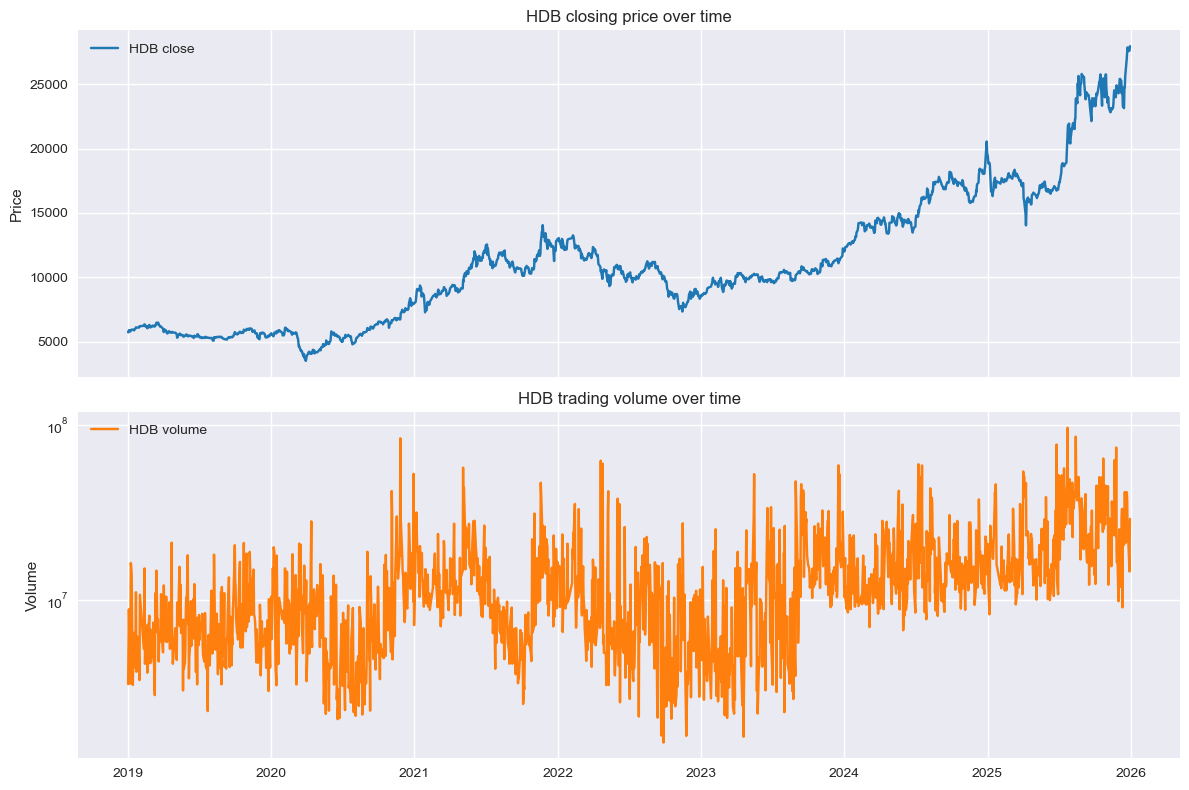

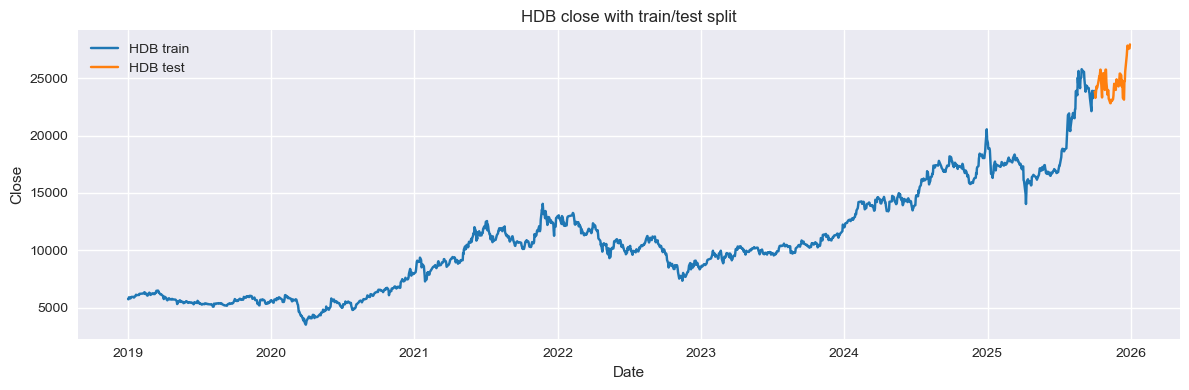

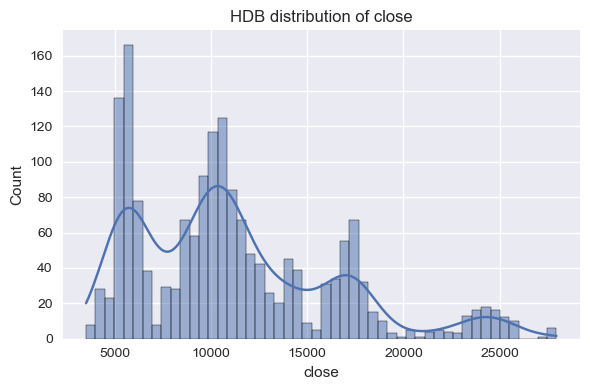

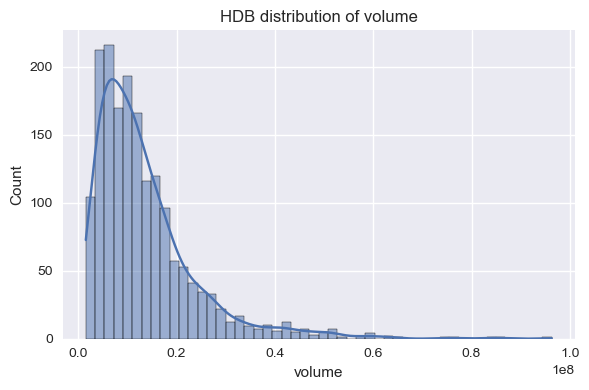

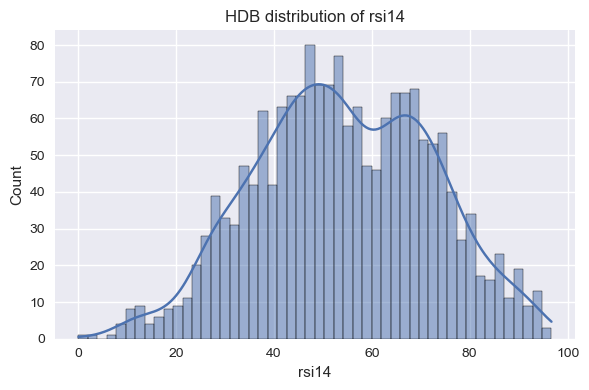

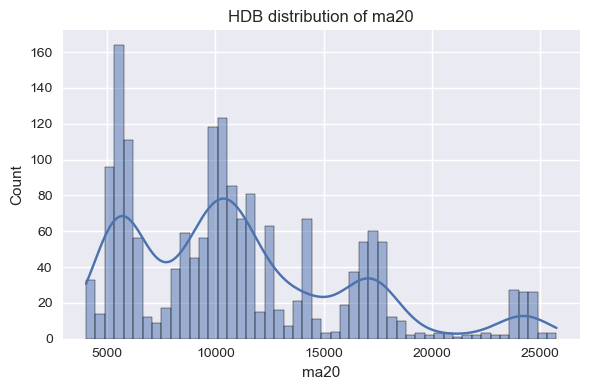

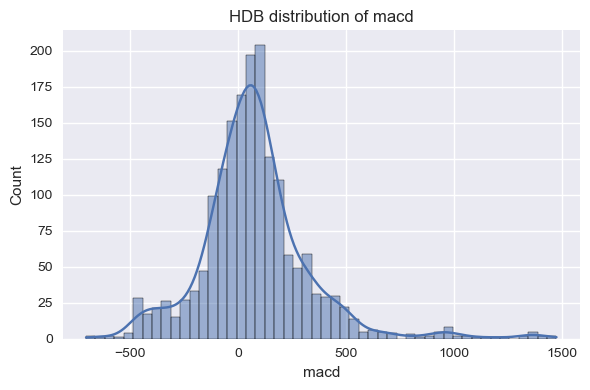

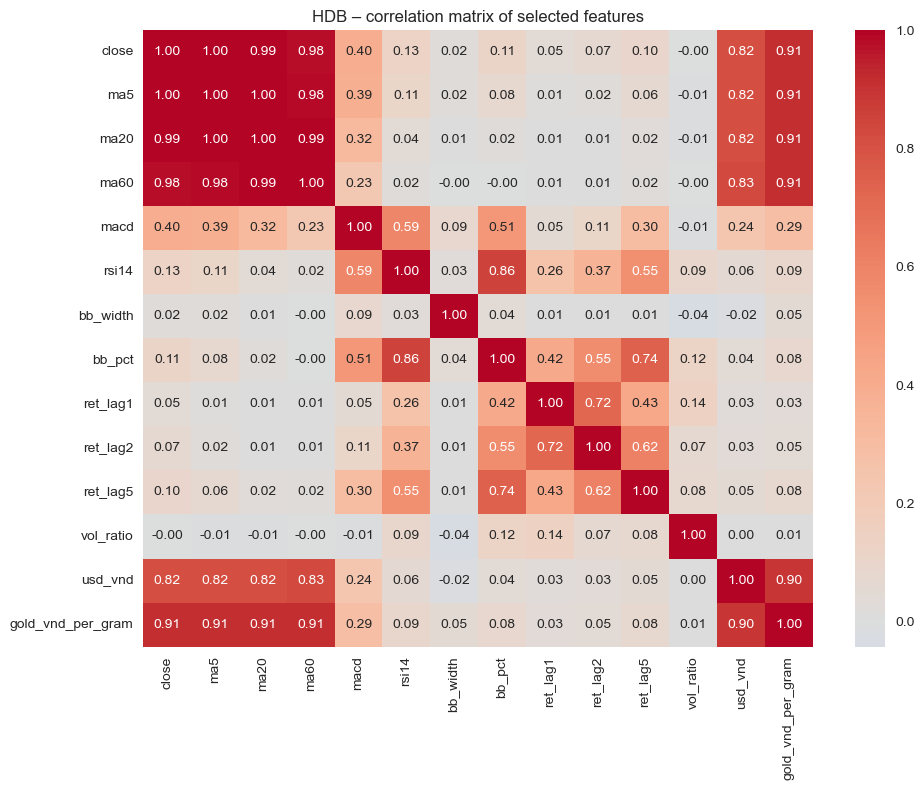


HDB correlation with close:
close                1.000000
ma5                  0.998554
ma20                 0.993503
ma60                 0.982194
gold_vnd_per_gram    0.912229
usd_vnd              0.819583
macd                 0.396306
rsi14                0.128316
bb_pct               0.110337
ret_lag5             0.103027
ret_lag2             0.065159
ret_lag1             0.047139
bb_width             0.018050
vol_ratio           -0.002310
Name: close, dtype: float64


In [7]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 80)

# -------- Load & filter to HDB only --------
df_full = pd.read_csv(r"C:\Users\PC\Desktop\Intern & Thesis\stock_dataset_full.csv")     # Load full dataset[file:18]
df_full["date"] = pd.to_datetime(df_full["date"], errors="coerce")  # Parse dates[file:18]

df_hdb = df_full[df_full["ticker"] == "HDB"].copy()    # Keep only HDB rows (one time series)[file:18]
df_hdb = df_hdb.sort_values("date").reset_index(drop=True)  # Ensure time order[file:18]

print("HDB shape:", df_hdb.shape)
print(df_hdb.head())

# -------- Basic info & missing values --------
print("\nHDB info:")
print(df_hdb.info())                                     # Types, non-null counts[file:18]

missing_hdb = df_hdb.isna().sum().sort_values(ascending=False)
print("\nHDB missing values:")
print(missing_hdb[missing_hdb > 0])                      # Columns with missing values[file:18]

# -------- Price & volume over time --------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_hdb["date"], df_hdb["close"], color="tab:blue", label="HDB close")  # Price path[file:18]
ax[0].set_title("HDB closing price over time")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(df_hdb["date"], df_hdb["volume"], color="tab:orange", label="HDB volume")  # Volume path[file:18]
ax[1].set_title("HDB trading volume over time")
ax[1].set_ylabel("Volume")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()

# -------- Train vs test split visualization --------
train_hdb = df_hdb[df_hdb["split"] == "train"]
test_hdb  = df_hdb[df_hdb["split"] == "test"]            # Last 3 months of 2025[file:18]

plt.figure(figsize=(12, 4))
plt.plot(train_hdb["date"], train_hdb["close"], color="tab:blue", label="HDB train")  # Train part[file:18]
plt.plot(test_hdb["date"],  test_hdb["close"],  color="tab:orange", label="HDB test") # Test part[file:18]
plt.title("HDB close with train/test split")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Distributions of key indicators --------
key_cols = ["close", "volume", "rsi14", "ma20", "ema12", "macd"]
key_cols = [c for c in key_cols if c in df_hdb.columns]  # Only keep existing columns[file:18]

for col in key_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_hdb[col].dropna(), bins=50, kde=True)
    plt.title(f"HDB distribution of {col}")
    plt.tight_layout()
    plt.show()

# -------- Correlation matrix (HDB) --------
corr_cols = [
    "close", "ma5", "ma20", "ma60", "ema12", "ema26",
    "macd", "rsi14", "bb_width", "bb_pct",
    "ret_lag1", "ret_lag2", "ret_lag5",
    "vol_ratio", "vni_close", "usd_vnd", "gold_vnd_per_gram"
]
corr_cols = [c for c in corr_cols if c in df_hdb.columns]  # Existing only[file:18]

corr_hdb = df_hdb[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_hdb, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("HDB – correlation matrix of selected features")
plt.tight_layout()
plt.show()

print("\nHDB correlation with close:")
print(corr_hdb["close"].sort_values(ascending=False))

TCB shape: (1745, 46)
        date   open   high    low  close   volume ticker         ma5  \
0 2019-01-02  11900  11923  11717  11717  2858060    TCB  11716.9814   
1 2019-01-03  11763  11786  11442  11442  3735160    TCB  11579.6729   
2 2019-01-04  11442  11442  10641  11419  6095660    TCB  11526.2751   
3 2019-01-07  11511  11671  11488  11488  3206860    TCB  11516.7397   
4 2019-01-08  11511  11534  11465  11488  1686340    TCB  11511.0186   

         ma20        ma60     macd  macd_signal  macd_hist  rsi14  bb_width  \
0  11716.9814  11716.9814   0.0000       0.0000     0.0000    NaN       NaN   
1  11579.6729  11579.6729 -21.9068      -4.3814   -17.5254   0.00    0.0671   
2  11526.2751  11526.2751 -40.6461     -11.6343   -29.0118   0.00    0.0575   
3  11516.7397  11516.7397 -49.3881     -19.1851   -30.2030  18.75    0.0474   
4  11511.0186  11511.0186 -55.6743     -26.4829   -29.1914  18.75    0.0413   

   bb_pct     atr14  ret_lag1  ret_lag2  ret_lag3  ret_lag5  ret_lag10

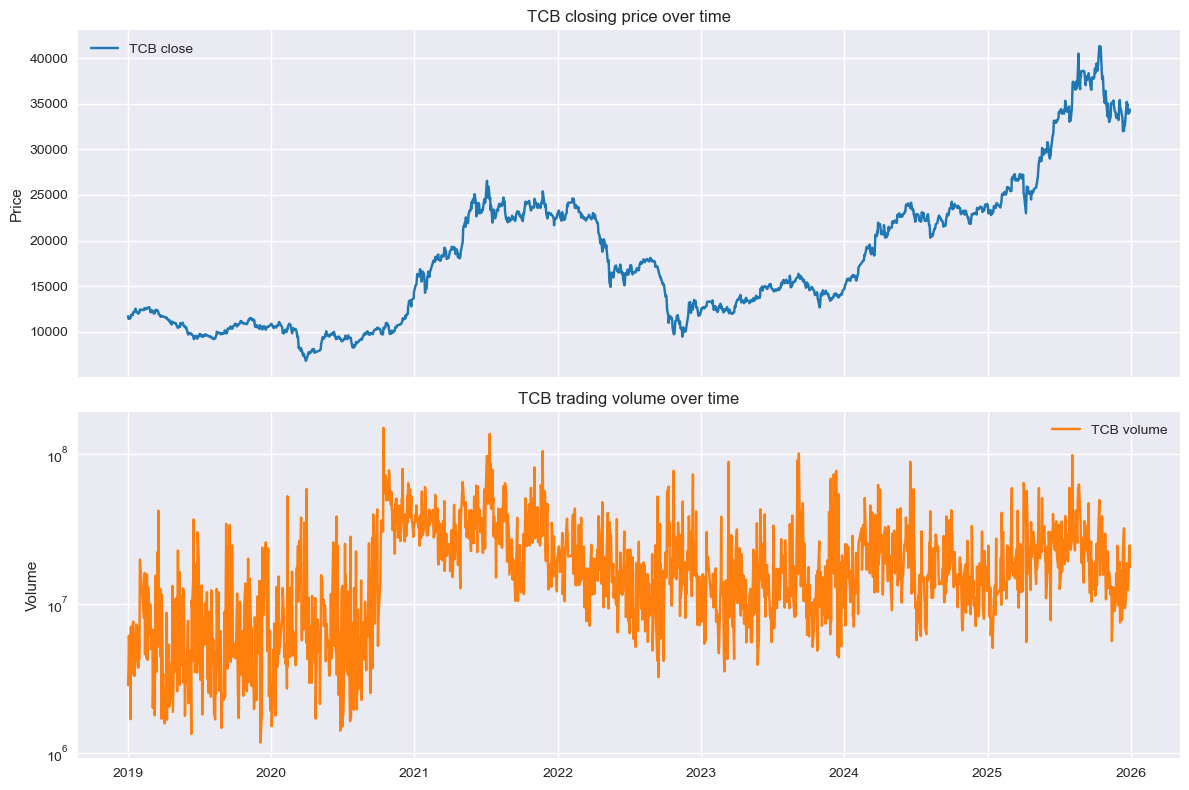

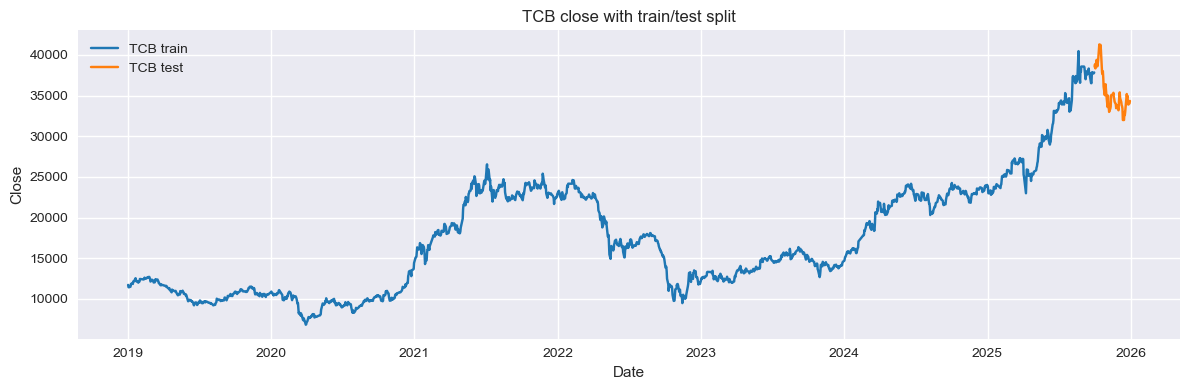

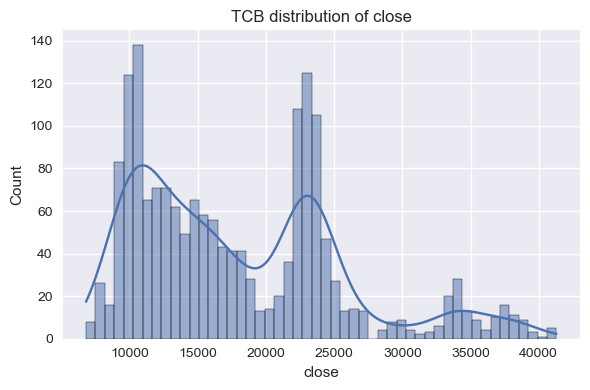

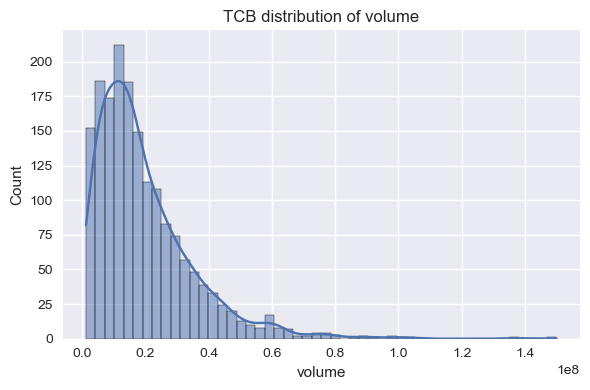

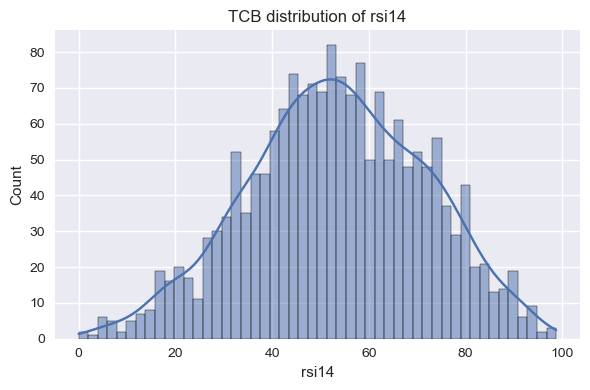

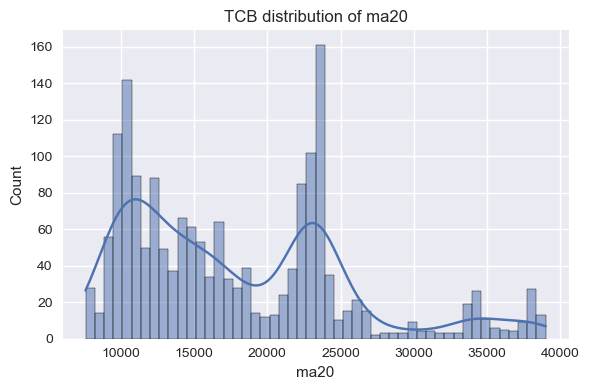

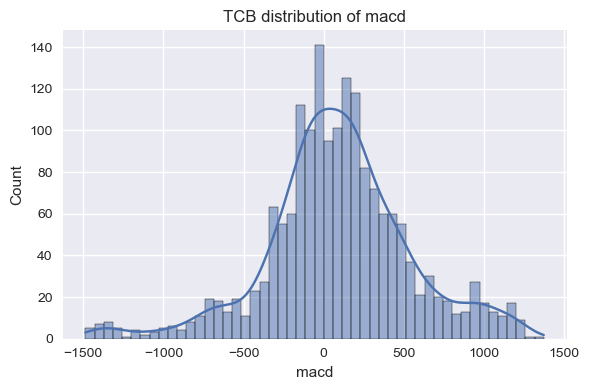

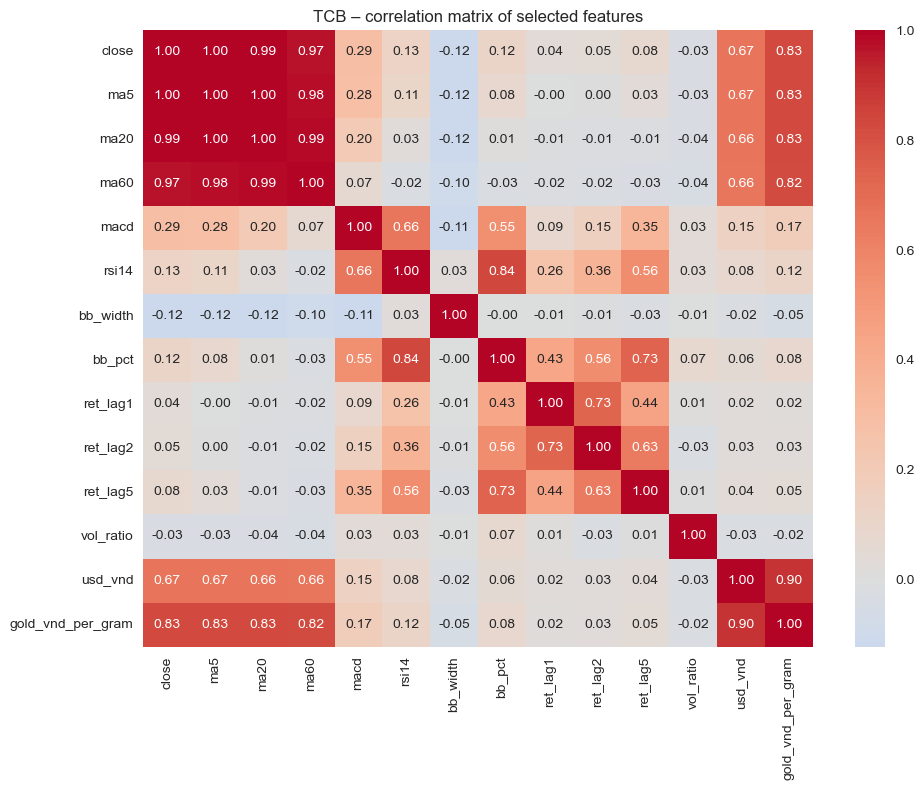


TCB correlation with close:
close                1.000000
ma5                  0.998421
ma20                 0.992246
ma60                 0.971753
gold_vnd_per_gram    0.826918
usd_vnd              0.667154
macd                 0.294244
rsi14                0.130127
bb_pct               0.116824
ret_lag5             0.075990
ret_lag2             0.048937
ret_lag1             0.035069
vol_ratio           -0.031239
bb_width            -0.121118
Name: close, dtype: float64


In [ ]:
df_tcb = df_full[df_full["ticker"] == "TCB"].copy()    # Keep only TCB rows[file:18]
df_tcb = df_tcb.sort_values("date").reset_index(drop=True)

print("TCB shape:", df_tcb.shape)
print(df_tcb.head())

# -------- Basic info & missing values --------
print("\nTCB info:")
print(df_tcb.info())

missing_tcb = df_tcb.isna().sum().sort_values(ascending=False)
print("\nTCB missing values:")
print(missing_tcb[missing_tcb > 0])

# -------- Price & volume over time --------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_tcb["date"], df_tcb["close"], color="tab:blue", label="TCB close")
ax[0].set_title("TCB closing price over time")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(df_tcb["date"], df_tcb["volume"], color="tab:orange", label="TCB volume")
ax[1].set_title("TCB trading volume over time")
ax[1].set_ylabel("Volume")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()

# -------- Train vs test split visualization --------
train_tcb = df_tcb[df_tcb["split"] == "train"]
test_tcb  = df_tcb[df_tcb["split"] == "test"]

plt.figure(figsize=(12, 4))
plt.plot(train_tcb["date"], train_tcb["close"], color="tab:blue", label="TCB train")
plt.plot(test_tcb["date"],  test_tcb["close"],  color="tab:orange", label="TCB test")
plt.title("TCB close with train/test split")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Distributions of key indicators --------
key_cols = ["close", "volume", "rsi14", "ma20", "ema12", "macd"]
key_cols = [c for c in key_cols if c in df_tcb.columns]

for col in key_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_tcb[col].dropna(), bins=50, kde=True)
    plt.title(f"TCB distribution of {col}")
    plt.tight_layout()
    plt.show()

# -------- Correlation matrix (TCB) --------
corr_cols = [
    "close", "ma5", "ma20", "ma60", "ema12", "ema26",
    "macd", "rsi14", "bb_width", "bb_pct",
    "ret_lag1", "ret_lag2", "ret_lag5",
    "vol_ratio", "vni_close", "usd_vnd", "gold_vnd_per_gram"
]
corr_cols = [c for c in corr_cols if c in df_tcb.columns]

corr_tcb = df_tcb[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_tcb, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("TCB – correlation matrix of selected features")
plt.tight_layout()
plt.show()

print("\nTCB correlation with close:")
print(corr_tcb["close"].sort_values(ascending=False))

TPB shape: (1748, 46)
        date  open  high   low  close   volume ticker        ma5       ma20  \
0 2019-01-02  6297  6297  6048   6188   294653    TPB  6188.0396  6188.0396   
1 2019-01-03  6173  6297  6002   6048   253981    TPB  6118.2498  6118.2498   
2 2019-01-04  6048  6048  5800   6033   472529    TPB  6089.8169  6089.8169   
3 2019-01-07  6235  6281  6033   6095   291326    TPB  6091.1093  6091.1093   
4 2019-01-08  6142  6235  6064   6110  4125215    TPB  6094.9864  6094.9864   

        ma60     macd  macd_signal  macd_hist    rsi14  bb_width  bb_pct  \
0  6188.0396   0.0000       0.0000     0.0000      NaN       NaN     NaN   
1  6118.2498 -11.1346      -2.2269    -8.9076   0.0000    0.0645  0.3232   
2  6089.8169 -20.9685      -5.9752   -14.9933   0.0000    0.0561  0.3336   
3  6091.1093 -23.4855      -9.4773   -14.0082  28.5714    0.0458  0.5139   
4  6094.9864 -23.9527     -12.3724   -11.5803  33.3333    0.0401  0.5635   

      atr14  ret_lag1  ret_lag2  ret_lag3  ret

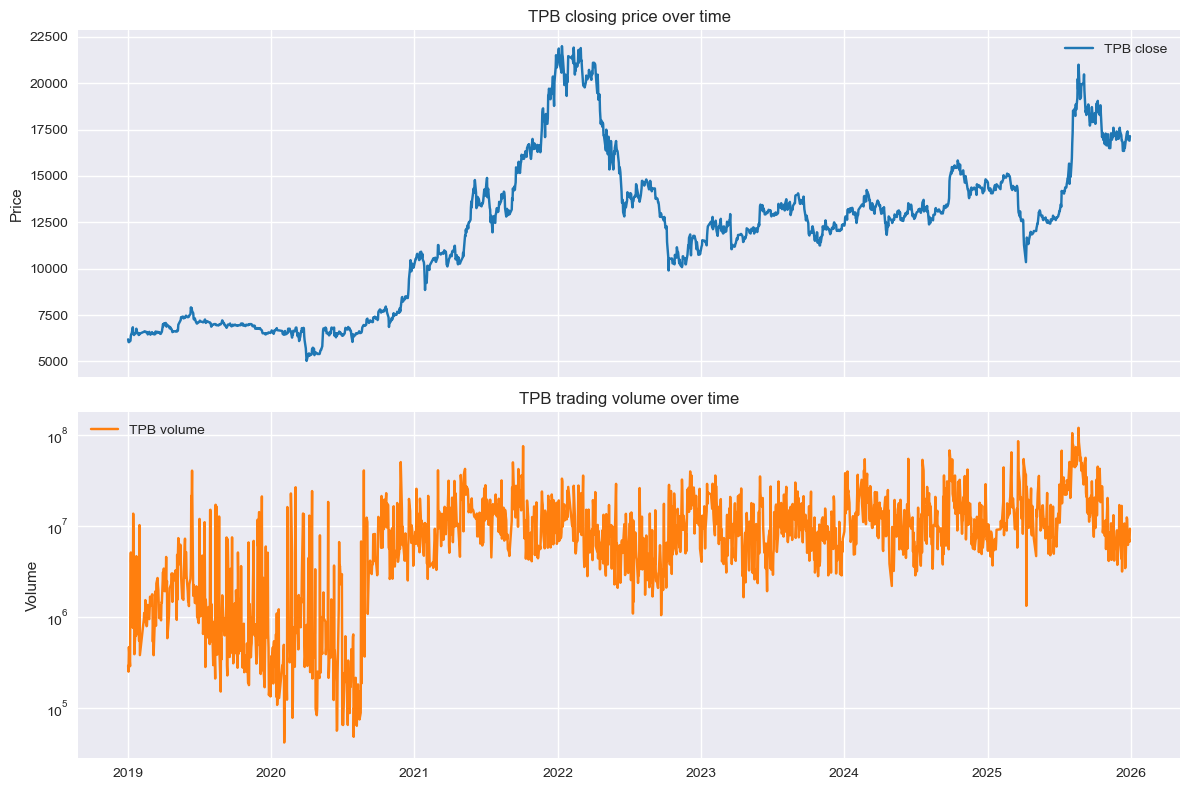

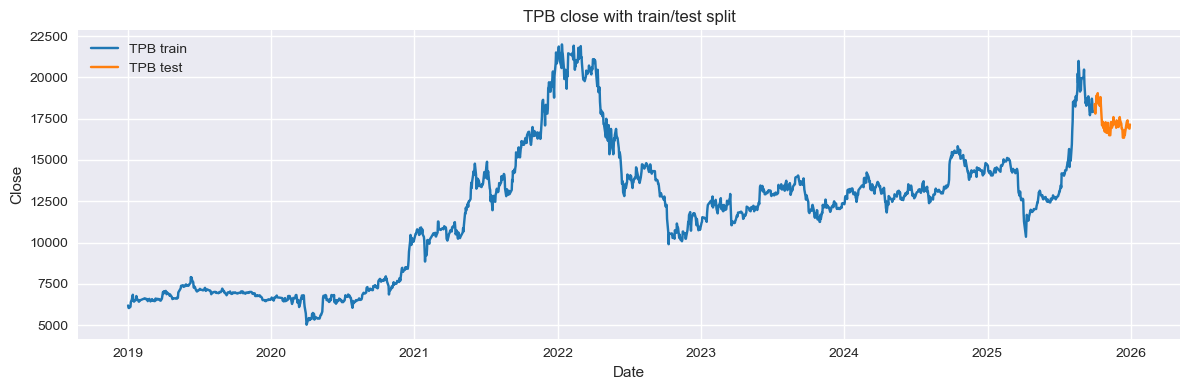

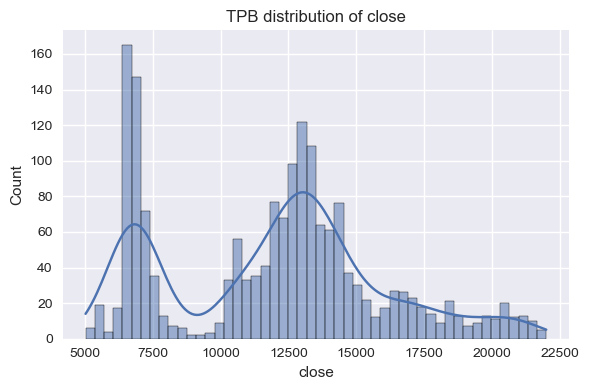

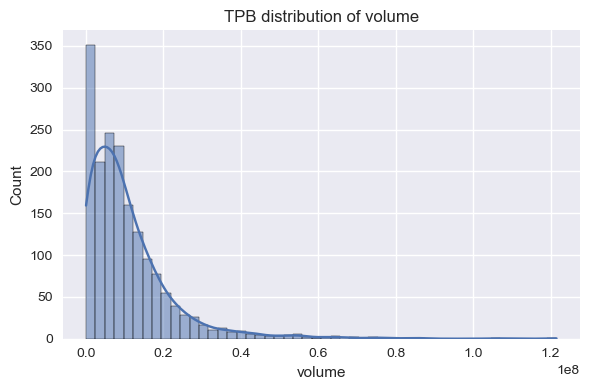

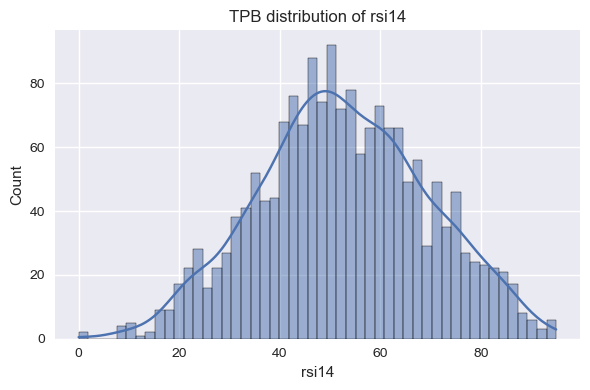

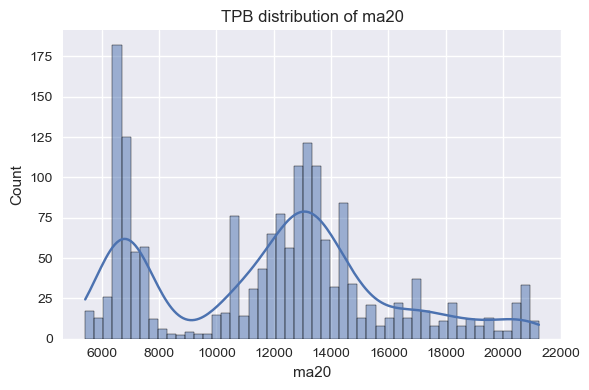

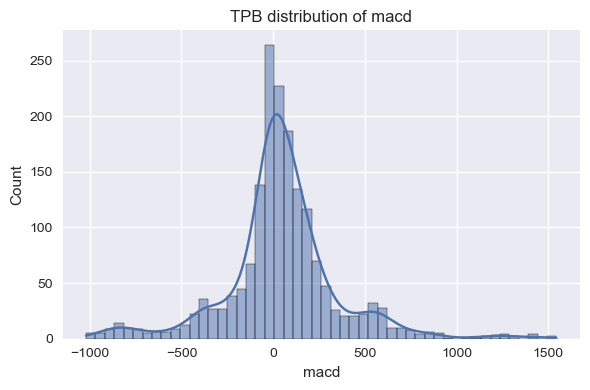

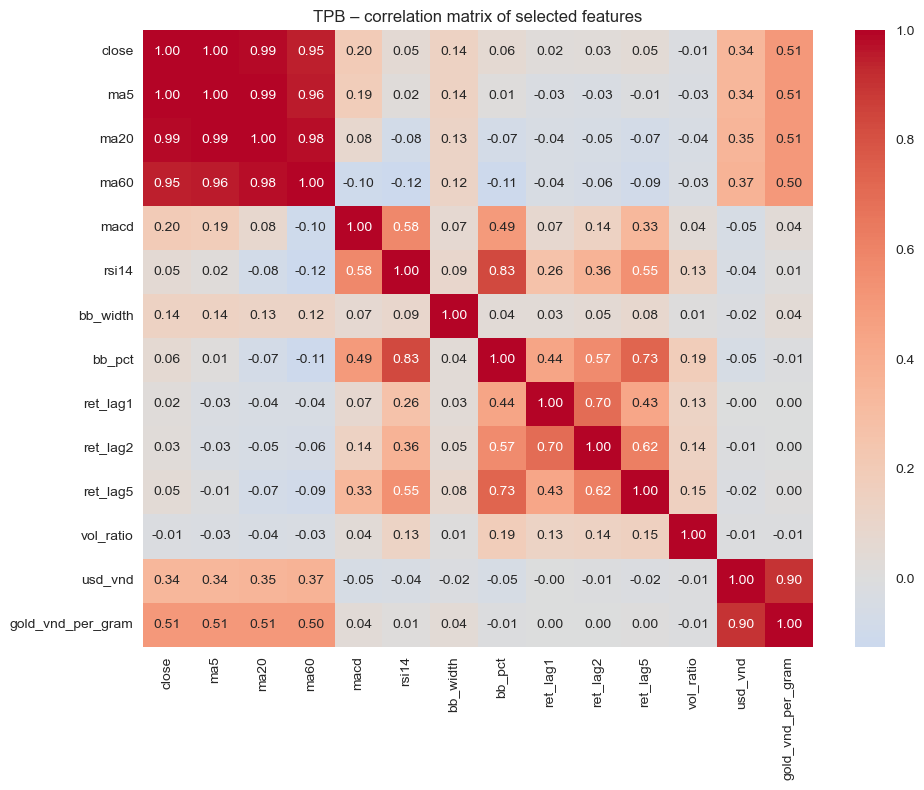


TPB correlation with close:
close                1.000000
ma5                  0.997337
ma20                 0.986370
ma60                 0.950796
gold_vnd_per_gram    0.505003
usd_vnd              0.341789
macd                 0.203094
bb_width             0.141312
bb_pct               0.061859
rsi14                0.051735
ret_lag5             0.046525
ret_lag2             0.032382
ret_lag1             0.024819
vol_ratio           -0.014889
Name: close, dtype: float64


In [9]:
df_tpb = df_full[df_full["ticker"] == "TPB"].copy()    # Keep only TPB rows[file:18]
df_tpb = df_tpb.sort_values("date").reset_index(drop=True)

print("TPB shape:", df_tpb.shape)
print(df_tpb.head())

# -------- Basic info & missing values --------
print("\nTPB info:")
print(df_tpb.info())

missing_tpb = df_tpb.isna().sum().sort_values(ascending=False)
print("\nTPB missing values:")
print(missing_tpb[missing_tpb > 0])

# -------- Price & volume over time --------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_tpb["date"], df_tpb["close"], color="tab:blue", label="TPB close")
ax[0].set_title("TPB closing price over time")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(df_tpb["date"], df_tpb["volume"], color="tab:orange", label="TPB volume")
ax[1].set_title("TPB trading volume over time")
ax[1].set_ylabel("Volume")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()

# -------- Train vs test split visualization --------
train_tpb = df_tpb[df_tpb["split"] == "train"]
test_tpb  = df_tpb[df_tpb["split"] == "test"]

plt.figure(figsize=(12, 4))
plt.plot(train_tpb["date"], train_tpb["close"], color="tab:blue", label="TPB train")
plt.plot(test_tpb["date"],  test_tpb["close"],  color="tab:orange", label="TPB test")
plt.title("TPB close with train/test split")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Distributions of key indicators --------
key_cols = ["close", "volume", "rsi14", "ma20", "ema12", "macd"]
key_cols = [c for c in key_cols if c in df_tpb.columns]

for col in key_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_tpb[col].dropna(), bins=50, kde=True)
    plt.title(f"TPB distribution of {col}")
    plt.tight_layout()
    plt.show()

# -------- Correlation matrix (TPB) --------
corr_cols = [
    "close", "ma5", "ma20", "ma60", "ema12", "ema26",
    "macd", "rsi14", "bb_width", "bb_pct",
    "ret_lag1", "ret_lag2", "ret_lag5",
    "vol_ratio", "vni_close", "usd_vnd", "gold_vnd_per_gram"
]
corr_cols = [c for c in corr_cols if c in df_tpb.columns]

corr_tpb = df_tpb[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_tpb, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("TPB – correlation matrix of selected features")
plt.tight_layout()
plt.show()

print("\nTPB correlation with close:")
print(corr_tpb["close"].sort_values(ascending=False))